In [6]:
import pandas as pd
import numpy as np


In [7]:
df = pd.read_csv("../data/spam.csv",encoding="latin-1")

In [8]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1879,spam,U have a secret admirer who is looking 2 make ...,NaN,NaN,NaN
3922,ham,Okay lor... Will they still let us go a not ah...,NaN,NaN,NaN
4212,ham,I attended but nothing is there.,NaN,NaN,NaN
5125,ham,After my work ah... Den 6 plus lor... U workin...,NaN,NaN,NaN
2131,ham,S...from the training manual it show there is ...,NaN,NaN,NaN


In [9]:
df.shape


(5572, 5)

In [10]:
#1.data cleaning
#2. eda
#3. text preprocessing
#4. model building
#5. evaluation 
#6. improvement
#7. website
#8. deploy

# data cleaning

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [15]:
# drop last 3 columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [16]:
df.sample(5)

,v1,v2
3851,ham,"No, its true..k,Do u knw dis no. &lt;#&gt; ?"
2007,ham,Hi here. have birth at on the to at 8lb 7oz....
1105,ham,on hen night. Going with a swing
109,ham,Dont worry. I guess he's busy.
4754,ham,U wan 2 haf lunch i'm in da canteen now.


In [18]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
3042,ham,Your bill at 3 is å£33.65 so thats not bad!
1456,ham,U sleeping now.. Or you going to take? Haha.. ...
2718,spam,18 days to Euro2004 kickoff! U will be kept in...
444,ham,\HEY HEY WERETHE MONKEESPEOPLE SAY WE MONKEYAR...
1917,ham,We not leaving yet. Ok lor then we go elsewher...


In [19]:
from sklearn.preprocessing import LabelEncoder

In [21]:
encoder= LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [22]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [24]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(403)

In [32]:
df = df.drop_duplicates(keep='first')

In [33]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.shape

(5169, 2)

#2.EDA

In [36]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [37]:
import matplotlib.pyplot as plt

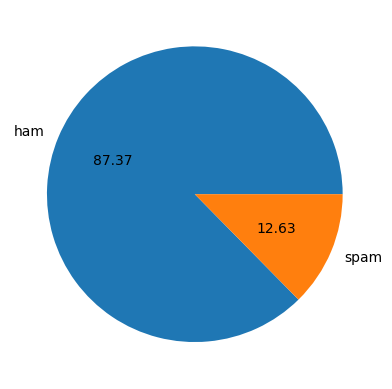

In [42]:
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

# Data is imbalanced


In [53]:
import nltk

In [45]:
!pip install nltk

In [54]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\khushi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [55]:
df['num_characters']=df['text'].apply(len)

In [56]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [59]:
df['num_words'] = df['text'].apply(lambda x: len(str(x).split()))


In [60]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13
